In [21]:
# Import required libraries for deep learning and visualization
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("OK")

OK


In [22]:
# Define dataset location
dataset_path = "data/PetImages"

In [23]:
# Load images from folders and automatically create labels from folder names
# Cat = one class, Dog = another class

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 2001 files belonging to 2 classes.
Using 1601 files for training.
Found 2001 files belonging to 2 classes.
Using 400 files for validation.


In [24]:
# Display class names detected from folders
class_names = train_data.class_names
print(class_names)

['Cat', 'Dog']


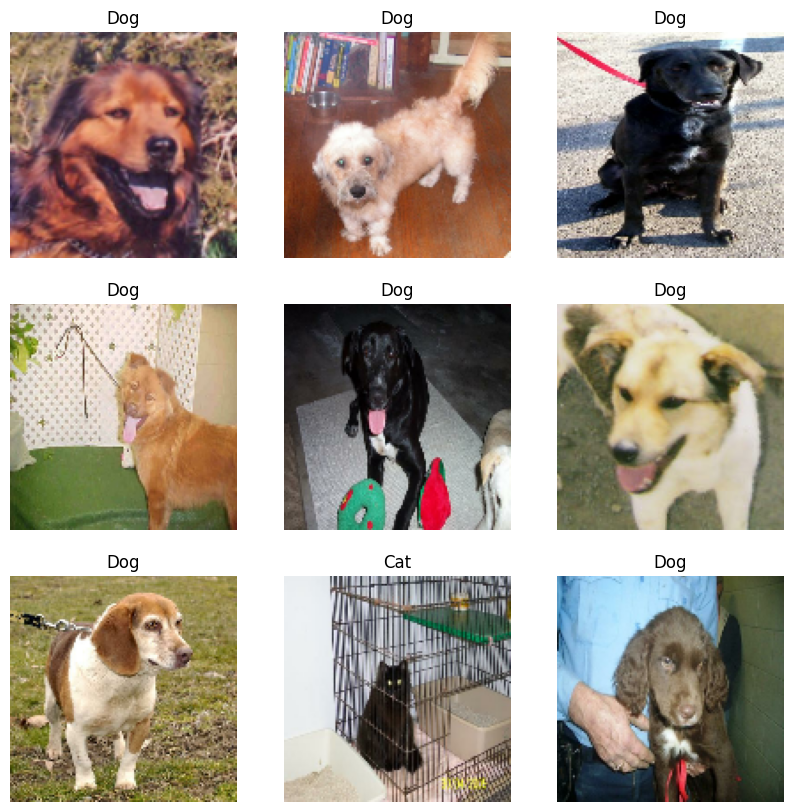

In [25]:
# Display several images from the training dataset
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [26]:
# Improve dataset loading performance
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)

In [27]:
# Build a Convolutional Neural Network for binary image classification

from tensorflow.keras import layers, models

model = models.Sequential([

    # Define input layer explicitly
    layers.Input(shape=(128, 128, 3)),

    # Normalize pixel values
    layers.Rescaling(1./255),

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    layers.Dropout(0.3),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Compile the CNN model
# Binary crossentropy is used because there are only two classes: Cat and Dog

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
# Find and remove images that TensorFlow cannot decode

import os
import tensorflow as tf

dataset_path = "data/PetImages"
bad_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            image_bytes = tf.io.read_file(file_path)
            image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
        except Exception as e:
            bad_files.append(file_path)

print("Bad files found:", len(bad_files))

for file_path in bad_files:
    print("Removing:", file_path)
    os.remove(file_path)

print("Bad files removed.")

Bad files found: 0
Bad files removed.


In [30]:
# Train the model and validate it after each epoch

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5347 - loss: 0.6948 - val_accuracy: 0.6200 - val_loss: 0.6748
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 50s 973ms/step - accuracy: 0.6240 - loss: 0.6488 - val_accuracy: 0.5975 - val_loss: 0.6361
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 49s 966ms/step - accuracy: 0.6652 - loss: 0.6083 - val_accuracy: 0.6850 - val_loss: 0.6080
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 29s 555ms/step - accuracy: 0.6952 - loss: 0.5752 - val_accuracy: 0.5825 - val_loss: 0.6480
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 521ms/step - accuracy: 0.7302 - loss: 0.5232 - val_accuracy: 0.6650 - val_loss: 0.6166


In [31]:
loss, accuracy = model.evaluate(val_data)
print(accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.6650 - loss: 0.6166
0.6650000214576721


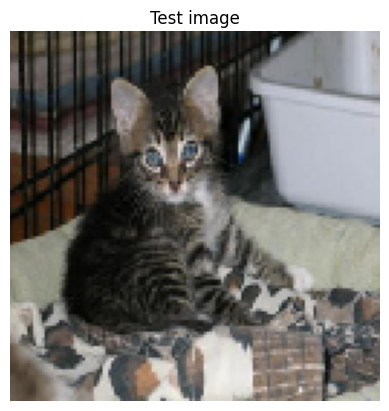

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Raw prediction: [[0.41313547]]
Predicted class: Cat (58.69%)


In [38]:
# Load one image manually
img_path = "data/PetImages/Cat/12.jpg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(128, 128)
)

# Show image
plt.imshow(img)
plt.title("Test image")
plt.axis("off")
plt.show()

# Convert image to array
img_array = tf.keras.utils.img_to_array(img)

# Add batch dimension
img_array = tf.expand_dims(img_array, 0)

# Predict
prediction = model.predict(img_array)

print("Raw prediction:", prediction)

# Convert probability to class
prob = prediction[0][0]

if prob > 0.5:
    print(f"Predicted class: Dog ({prob*100:.2f}%)")
else:
    print(f"Predicted class: Cat ({(1-prob)*100:.2f}%)")

In [39]:
## CNN Architecture

This Convolutional Neural Network consists of:
- Convolutional layers for feature extraction
- MaxPooling layers for dimensionality reduction
- Dense layers for classification
- Dropout layer to reduce overfitting

The model is designed for binary image classification: Cat vs Dog.

SyntaxError: invalid syntax (2140708404.py, line 3)